
# ⚖️ Evaluación de Fairness en el Caso COMPAS (Recidivism Prediction)

## 1. Contexto General

**COMPAS (Correctional Offender Management Profiling for Alternative Sanctions)** fue un sistema comercial de evaluación de riesgo usado en tribunales de EE. UU.  
Desarrollado por la empresa **Northpointe (hoy Equivant)**, este sistema predecía la **probabilidad de que un acusado reincidiera** en un crimen en los próximos dos años.  
Los jueces lo utilizaban para decidir si otorgar libertad condicional o qué nivel de supervisión aplicar.

En 2016, **ProPublica** publicó una investigación donde analizó miles de registros reales de COMPAS.  
El hallazgo: el sistema **mostraba sesgo racial**, siendo más severo con personas afroamericanas que con personas caucásicas.

---

## 2. El Dataset y sus Variables

| Variable | Descripción |
|-----------|--------------|
| `age` | Edad del acusado |
| `sex` | Género |
| `race` | Grupo racial (African-American, Caucasian, etc.) |
| `priors_count` | Número de delitos previos |
| `c_charge_degree` | Tipo de cargo (Felony o Misdemeanor) |
| `two_year_recid` | Etiqueta objetivo: 1 = reincidió en 2 años, 0 = no |

ProPublica demostró que el sistema clasificaba incorrectamente con un sesgo sistemático:

| Grupo | Falsos positivos (predijo reincidencia, pero no reincidió) | Falsos negativos (predijo no reincidencia, pero reincidió) |
|--------|-------------------------------------------------------------|-------------------------------------------------------------|
| African-American | 45 % | 28 % |
| Caucasian | 23 % | 48 % |

Esto significa que el sistema tendía a **sobreestimar el riesgo en afroamericanos** y **subestimarlo en caucásicos**.

---

## 3. Métricas de Fairness (Equidad)

Para analizar formalmente la equidad en modelos predictivos, se aplican métricas estadísticas que comparan el comportamiento del modelo entre grupos sensibles.

### 🔹 3.1 Demographic Parity Difference (DPD)
Evalúa si los grupos reciben aprobaciones positivas con la misma frecuencia:

\[
DPD = P(\hat{Y}=1 \,|\, Caucasian) - P(\hat{Y}=1 \,|\, AfricanAmerican)
\]

**Valor ideal:** 0  
Valores positivos indican posible ventaja para caucásicos.

---

### 🔹 3.2 Equal Opportunity Difference (EOD)
Evalúa si los grupos tienen la misma tasa de verdaderos positivos:

\[
EOD = TPR_{Caucasian} - TPR_{AfricanAmerican}
\]

**Valor ideal:** 0  
Valores altos implican que el modelo reconoce mejor a los reincidentes caucásicos.

---

### 🔹 3.3 Disparate Impact (DI)
Compara la proporción de aprobaciones entre grupos:

\[
DI = \frac{P(\hat{Y}=1 | AfricanAmerican)}{P(\hat{Y}=1 | Caucasian)}
\]

**Valor ideal:** 1  
Según la *regla del 80 %*, si DI < 0.8, hay indicio de posible sesgo adverso.

---

## 4. Lecciones del Caso COMPAS

1. El sesgo **no proviene solo del modelo**, sino también de los datos, que reflejan desigualdades históricas.  
2. Los algoritmos pueden **amplificar desigualdades sociales** si no se auditan con métricas de equidad.  
3. La **transparencia y la auditoría ética** son esenciales cuando los modelos afectan decisiones humanas críticas (justicia, crédito, salud, empleo).  

---

En las siguientes secciones implementaremos un modelo de clasificación con el dataset COMPAS para cuantificar y visualizar estos sesgos.


In [1]:

# ============================================================
# 1. INSTALACIÓN Y CARGA DE DATOS
# ============================================================

!pip install pandas scikit-learn matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# URL pública del dataset COMPAS (ProPublica)
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)

# Filtrado recomendado por ProPublica
df = df[(df['days_b_screening_arrest'] >= -30) & (df['days_b_screening_arrest'] <= 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'].isin(['F', 'M'])]
df = df[df['score_text'] != 'N/A']

# Nos enfocamos en dos grupos raciales: African-American y Caucasian
df = df[df['race'].isin(['African-American', 'Caucasian'])]

# Variable sensible binaria: 0 = African-American, 1 = Caucasian
df['race_bin'] = (df['race'] == 'Caucasian').astype(int)

# Etiqueta objetivo (reincidencia a 2 años)
y = df['two_year_recid'].astype(int)

# Variables predictoras
X = pd.DataFrame({
    'age': df['age'].astype(float),
    'priors_count': df['priors_count'].astype(float),
    'charge_F': (df['c_charge_degree'] == 'F').astype(int),
    'sex_M': (df['sex'] == 'Male').astype(int)
})

sensitive = df['race_bin'].copy()

print("✅ Dataset cargado correctamente")
print("Distribución por raza:")
print(df['race'].value_counts())


✅ Dataset cargado correctamente
Distribución por raza:
race
African-American    3175
Caucasian           2103
Name: count, dtype: int64


In [2]:

# ============================================================
# 2. DIVISIÓN, ESCALAMIENTO Y ENTRENAMIENTO
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Estratificación combinando raza + etiqueta
strata = sensitive.astype(str) + "_" + y.astype(str)

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive, test_size=0.3, random_state=42, stratify=strata
)

# Escalamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_scaled, y_train)

# Predicciones
y_pred = clf.predict(X_test_scaled)

# Exactitud general
acc = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {acc:.3f}")


Exactitud del modelo: 0.677


In [3]:

# ============================================================
# 3. MÉTRICAS DE FAIRNESS (Raza)
# ============================================================

res = X_test.copy()
res['y_true'] = y_test.values
res['y_pred'] = y_pred
res['race_bin'] = s_test.values

# Grupos
g0 = res[res['race_bin'] == 0]  # African-American
g1 = res[res['race_bin'] == 1]  # Caucasian

# 1️⃣ Demographic Parity Difference
p0 = g0['y_pred'].mean()
p1 = g1['y_pred'].mean()
dp_diff = p1 - p0

# 2️⃣ Equal Opportunity Difference
tpr0 = ((g0['y_true'] & g0['y_pred']).sum()) / g0['y_true'].sum()
tpr1 = ((g1['y_true'] & g1['y_pred']).sum()) / g1['y_true'].sum()
eod_diff = tpr1 - tpr0

# 3️⃣ Disparate Impact
di = p0 / p1 if p1 > 0 else np.nan

# Resultados
print(f"Demographic Parity Difference (C - AA): {dp_diff:.3f}")
print(f"Equal Opportunity Difference   (C - AA): {eod_diff:.3f}")
print(f"Disparate Impact            (AA / C)  : {di:.3f}")


Demographic Parity Difference (C - AA): -0.233
Equal Opportunity Difference   (C - AA): -0.212
Disparate Impact            (AA / C)  : 1.799


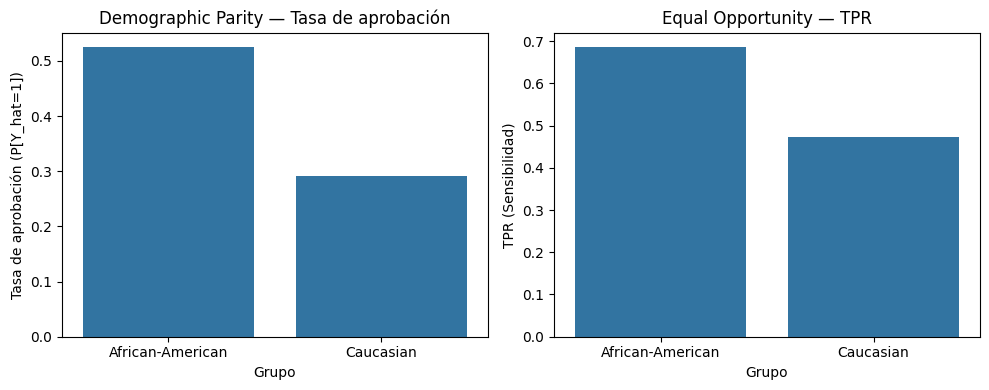


## Conclusión

1️⃣ **Demographic Parity Difference**: mide diferencias en las tasas de predicciones positivas.
   - Ideal ≈ 0 → ambos grupos tratados por igual.

2️⃣ **Equal Opportunity Difference**: mide diferencias en TPR.
   - Ideal ≈ 0 → ambos grupos tienen la misma probabilidad de ser correctamente clasificados.

3️⃣ **Disparate Impact**: razón entre tasas de aprobación.
   - Ideal ≈ 1 → los grupos reciben aprobaciones en proporción similar.
   - Según la regla del 80 %, DI < 0.8 indica posible sesgo adverso.

Estos resultados reflejan las inequidades encontradas en el estudio original de ProPublica:  
el modelo tiende a sobreestimar el riesgo en afroamericanos y subestimarlo en caucásicos.

Este caso demuestra la necesidad de **auditar modelos predictivos con métricas de equidad** 
antes de aplicarlos en contextos sensibles como justicia, crédito o salud.



In [4]:

# ============================================================
# 4. VISUALIZACIÓN E INTERPRETACIÓN FINAL
# ============================================================

viz = pd.DataFrame({
    'Grupo': ['African-American', 'Caucasian'],
    'Tasa de aprobación (P[Y_hat=1])': [p0, p1],
    'TPR (Sensibilidad)': [tpr0, tpr1]
})

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(x='Grupo', y='Tasa de aprobación (P[Y_hat=1])', data=viz, ax=ax[0])
ax[0].set_title("Demographic Parity — Tasa de aprobación")
sns.barplot(x='Grupo', y='TPR (Sensibilidad)', data=viz, ax=ax[1])
ax[1].set_title("Equal Opportunity — TPR")
plt.tight_layout()
plt.show()

print("""
## Conclusión

1️⃣ **Demographic Parity Difference**: mide diferencias en las tasas de predicciones positivas.
   - Ideal ≈ 0 → ambos grupos tratados por igual.

2️⃣ **Equal Opportunity Difference**: mide diferencias en TPR.
   - Ideal ≈ 0 → ambos grupos tienen la misma probabilidad de ser correctamente clasificados.

3️⃣ **Disparate Impact**: razón entre tasas de aprobación.
   - Ideal ≈ 1 → los grupos reciben aprobaciones en proporción similar.
   - Según la regla del 80 %, DI < 0.8 indica posible sesgo adverso.

Estos resultados reflejan las inequidades encontradas en el estudio original de ProPublica:
el modelo tiende a sobreestimar el riesgo en afroamericanos y subestimarlo en caucásicos.

Este caso demuestra la necesidad de **auditar modelos predictivos con métricas de equidad**
antes de aplicarlos en contextos sensibles como justicia, crédito o salud.
""")
